In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (f1_score, accuracy_score,
                             precision_score, recall_score,
                             roc_auc_score, confusion_matrix,
                             classification_report)
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

# Set path once — change only here if needed
path = '/content/drive/MyDrive/DSPL/'
save_path = '/content/drive/MyDrive/DSPL/'

# Create save folder if not exists
os.makedirs(save_path, exist_ok=True)

train = pd.read_csv('/content/drive/MyDrive/DSPL/Hotel-A-train.csv')
validation = pd.read_csv('/content/drive/MyDrive/DSPL/Hotel-A-validation.csv')
test = pd.read_csv('/content/drive/MyDrive/DSPL/Hotel-A-test.csv')

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)

Train shape: (27499, 24)
Validation shape: (2749, 24)
Test shape: (4318, 23)


In [4]:
for df in [train, validation, test]:
    # Date conversions
    df['Booking_date'] = pd.to_datetime(df['Booking_date'])
    df['Expected_checkin'] = pd.to_datetime(df['Expected_checkin'])
    df['Expected_checkout'] = pd.to_datetime(df['Expected_checkout'])

    # Convert numeric columns
    for col in ['Adults', 'Children', 'Babies',
                'Room_Rate', 'Previous_Cancellations',
                'Income', 'Discount_Rate']:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    # Core features
    df['Lead_Time'] = (df['Expected_checkin'] -
                       df['Booking_date']).dt.days
    df['Length_of_Stay'] = (df['Expected_checkout'] -
                            df['Expected_checkin']).dt.days

    # Only keep proven useful engineered features
    df['high_risk_flag'] = ((df['Lead_Time'] > 100) &
                            (df['Deposit_type'] == 'No Deposit')).astype(int)
    df['family_size'] = (df['Adults'] +
                         df['Children'] +
                         df['Babies'])
    df['revenue_risk'] = df['Room_Rate'] * df['Lead_Time']


print("New shape:", train.shape)

New shape: (27499, 29)


In [5]:
for df in [train, validation]:
    df['Reservation_Status'] = df['Reservation_Status'].replace(
        {'Check-out': 'Check-Out'})

# Clean train
train = train[train['Lead_Time'] >= 0]
train = train[train['Length_of_Stay'] > 0]
train = train.dropna(subset=['Deposit_type',
                              'Visted_Previously',
                              'Room_Rate'])

# Clean validation
validation = validation[validation['Lead_Time'] >= 0]
validation = validation[validation['Length_of_Stay'] > 0]
validation = validation.dropna(subset=['Deposit_type',
                                        'Visted_Previously',
                                        'Room_Rate'])

print("After cleaning:")
print("Train:", train.shape)
print("Validation:", validation.shape)
print()
print("Status distribution:")
print(train['Reservation_Status'].value_counts())

After cleaning:
Train: (26993, 29)
Validation: (2733, 29)

Status distribution:
Reservation_Status
Check-Out    20777
Canceled      4108
No-Show       2108
Name: count, dtype: int64


In [6]:
drop_cols = ['Reservation-id', 'Booking_date',
             'Expected_checkin', 'Expected_checkout']

train = train.drop(columns=drop_cols, errors='ignore')
validation = validation.drop(columns=drop_cols, errors='ignore')
test = test.drop(columns=drop_cols, errors='ignore')

print("Columns after drop:")
print(list(train.columns))

Columns after drop:
['Gender', 'Age', 'Ethnicity', 'Educational_Level', 'Income', 'Country_region', 'Hotel_Type', 'Adults', 'Children', 'Babies', 'Meal_Type', 'Visted_Previously', 'Previous_Cancellations', 'Deposit_type', 'Booking_channel', 'Required_Car_Parking', 'Reservation_Status', 'Use_Promotion', 'Discount_Rate', 'Room_Rate', 'Lead_Time', 'Length_of_Stay', 'high_risk_flag', 'family_size', 'revenue_risk']


In [7]:
y_train = train['Reservation_Status']
y_val = validation['Reservation_Status']

X_train = train.drop(columns=['Reservation_Status'])
X_val = validation.drop(columns=['Reservation_Status'])

print("Shapes:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print()
print("Class distribution:")
print(y_train.value_counts())

Shapes:
X_train: (26993, 24)
X_val: (2733, 24)

Class distribution:
Reservation_Status
Check-Out    20777
Canceled      4108
No-Show       2108
Name: count, dtype: int64


In [8]:
le = LabelEncoder()

# Fix ALL status labels before encoding
status_mapping = {
    'Check-out': 'Check-Out',
    'Check-in': 'Check-Out',
    'Check-In': 'Check-Out',
    'Checkin': 'Check-Out',
    'CheckIn': 'Check-Out'
}

train['Reservation_Status'] = train['Reservation_Status'].replace(status_mapping)
validation['Reservation_Status'] = validation['Reservation_Status'].replace(status_mapping)

# Keep only valid 3 classes
valid_statuses = ['Check-Out', 'Canceled', 'No-Show']
train = train[train['Reservation_Status'].isin(valid_statuses)]
validation = validation[validation['Reservation_Status'].isin(valid_statuses)]

# Split features and target again after cleaning
y_train = train['Reservation_Status']
y_val = validation['Reservation_Status']
X_train = train.drop(columns=['Reservation_Status'])
X_val = validation.drop(columns=['Reservation_Status'])

# Encode features
all_X = pd.concat([X_train, X_val, test], ignore_index=True)
cat_cols = X_train.select_dtypes(include='object').columns

print("Encoding columns:", list(cat_cols))

for col in cat_cols:
    le_feat = LabelEncoder()
    le_feat.fit(all_X[col].astype(str))
    X_train[col] = le_feat.transform(X_train[col].astype(str))
    X_val[col] = le_feat.transform(X_val[col].astype(str))
    test[col] = le_feat.transform(test[col].astype(str))

# Encode target
le.fit(y_train)
y_train_enc = le.transform(y_train)
y_val_enc = le.transform(y_val)

print("Classes:", le.classes_)
print("Label encoding done!")
print()
print("Train size:", len(X_train))
print("Val size:", len(X_val))

Encoding columns: ['Gender', 'Ethnicity', 'Educational_Level', 'Country_region', 'Hotel_Type', 'Meal_Type', 'Visted_Previously', 'Deposit_type', 'Booking_channel', 'Required_Car_Parking', 'Use_Promotion']
Classes: ['Canceled' 'Check-Out' 'No-Show']
Label encoding done!

Train size: 26993
Val size: 2733


In [9]:
smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train_enc)

print("After SMOTETomek:")
print(pd.Series(y_train_res).value_counts())
print("Balanced shape:", X_train_res.shape)

After SMOTETomek:
2    19920
0    19772
1    19363
Name: count, dtype: int64
Balanced shape: (59055, 24)


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_val_scaled = scaler.transform(X_val)

print("Scaling done!")

Scaling done!


In [11]:
results = []

def evaluate_model(name, model, X_tr, y_tr, X_v, y_v):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_v)

    try:
        y_prob = model.predict_proba(X_v)
        roc = roc_auc_score(y_v, y_prob,
                            multi_class='ovr',
                            average='macro')
    except:
        roc = 0.0

    acc = accuracy_score(y_v, y_pred)
    prec = precision_score(y_v, y_pred,
                           average='macro',
                           zero_division=0)
    rec = recall_score(y_v, y_pred,
                       average='macro',
                       zero_division=0)
    f1 = f1_score(y_v, y_pred,
                  average='macro',
                  zero_division=0)

    results.append([name,
                    round(acc, 6),
                    round(prec, 6),
                    round(rec, 6),
                    round(f1, 6),
                    round(roc, 6)])

    print(f"{name}: F1={round(f1,3)}, Acc={round(acc,3)}")
    return model

In [12]:
print("=== TRAINING ALL MODELS ===")
print()

# 1. Logistic Regression
lr = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)
evaluate_model("Logistic Regression", lr,
               X_train_scaled, y_train_res,
               X_val_scaled, y_val_enc)

# 2. Decision Tree
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)
evaluate_model("Decision Tree", dt,
               X_train_res, y_train_res,
               X_val, y_val_enc)

# 3. Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
evaluate_model("Random Forest", rf,
               X_train_res, y_train_res,
               X_val, y_val_enc)

# 4. XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)
evaluate_model("XGBoost", xgb,
               X_train_res, y_train_res,
               X_val, y_val_enc)

# 5. ANN
ann = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42,
    early_stopping=True
)
evaluate_model("ANN", ann,
               X_train_scaled, y_train_res,
               X_val_scaled, y_val_enc)

=== TRAINING ALL MODELS ===

Logistic Regression: F1=0.305, Acc=0.519
Decision Tree: F1=0.339, Acc=0.456
Random Forest: F1=0.31, Acc=0.537
XGBoost: F1=0.304, Acc=0.539
ANN: F1=0.337, Acc=0.503


MLPClassifier(early_stopping=True, hidden_layer_sizes=(128, 64, 32),
              max_iter=500, random_state=42)

In [13]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision",
             "Recall", "F1 Score", "ROC-AUC"]
)

print("=== MODEL COMPARISON ===")
print(results_df.to_string())
print()

best_row = results_df.loc[results_df["F1 Score"].idxmax()]
best_model_name = best_row["Model"]
print("Best Model:", best_model_name)
print("Best Macro F1:", round(best_row["F1 Score"], 3))

=== MODEL COMPARISON ===
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.519210   0.326029  0.330293  0.305014  0.495124
1        Decision Tree  0.455909   0.346385  0.348723  0.338783  0.516642
2        Random Forest  0.537139   0.341320  0.337741  0.310300  0.511072
3              XGBoost  0.538602   0.334464  0.335407  0.304261  0.508028
4                  ANN  0.503476   0.351818  0.347947  0.336750  0.521576

Best Model: Decision Tree
Best Macro F1: 0.339


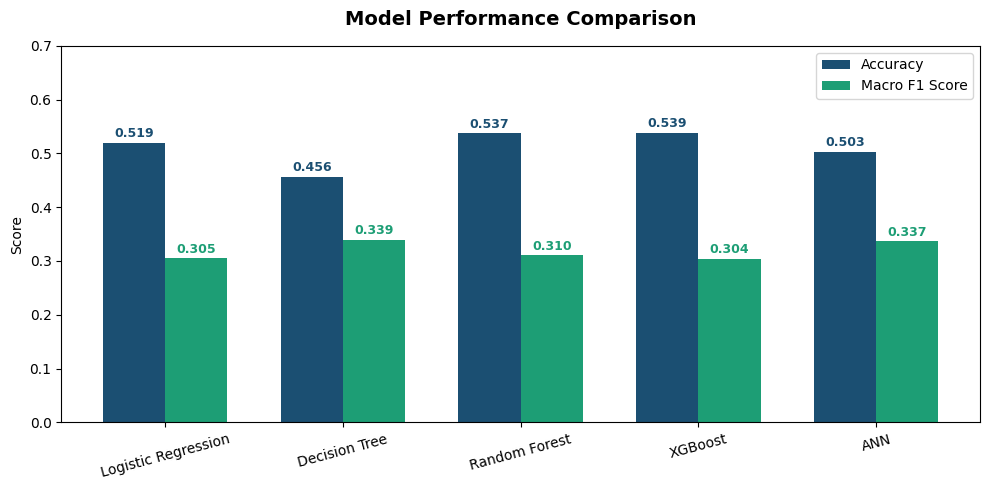

In [14]:
models = results_df['Model'].tolist()
f1 = results_df['F1 Score'].tolist()
acc = results_df['Accuracy'].tolist()

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, acc, width,
               label='Accuracy', color='#1B4F72')
bars2 = ax.bar(x + width/2, f1, width,
               label='Macro F1 Score', color='#1D9E75')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold',
            color='#1B4F72')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold',
            color='#1D9E75')

ax.set_title('Model Performance Comparison',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.set_ylabel('Score')
ax.set_ylim(0, 0.7)
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DSPL/chart1_model_comparison.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


In [15]:
if best_model_name == "Logistic Regression":
    final_model = LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42)
    final_model.fit(X_train_scaled, y_train_res)
    X_test_final = scaler.transform(test)

elif best_model_name == "Decision Tree":
    final_model = DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42)
    final_model.fit(X_train_res, y_train_res)
    X_test_final = test

elif best_model_name == "Random Forest":
    final_model = RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1)
    final_model.fit(X_train_res, y_train_res)
    X_test_final = test

elif best_model_name == "XGBoost":
    final_model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42,
        eval_metric='mlogloss')
    final_model.fit(X_train_res, y_train_res)
    X_test_final = test

elif best_model_name == "ANN":
    final_model = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        learning_rate_init=0.001,
        max_iter=500,
        random_state=42,
        early_stopping=True)
    final_model.fit(X_train_scaled, y_train_res)
    X_test_final = scaler.transform(test)



In [16]:
test_pred = final_model.predict(X_test_final)
test_pred_labels = le.inverse_transform(test_pred)

print("Sample predictions:", test_pred_labels[:10])
print()
pred_counts = pd.Series(test_pred_labels).value_counts()
print("Prediction distribution:")
print(pred_counts)
total = len(test_pred_labels)
total_risk = (pred_counts.get('Canceled', 0) +
              pred_counts.get('No-Show', 0))
print(f"\nHigh risk: {total_risk:,} ({total_risk/total*100:.2f}%)")

Sample predictions: ['No-Show' 'No-Show' 'No-Show' 'Canceled' 'Check-Out' 'No-Show' 'No-Show'
 'No-Show' 'No-Show' 'Check-Out']

Prediction distribution:
Check-Out    2762
No-Show       915
Canceled      641
Name: count, dtype: int64

High risk: 1,556 (36.04%)


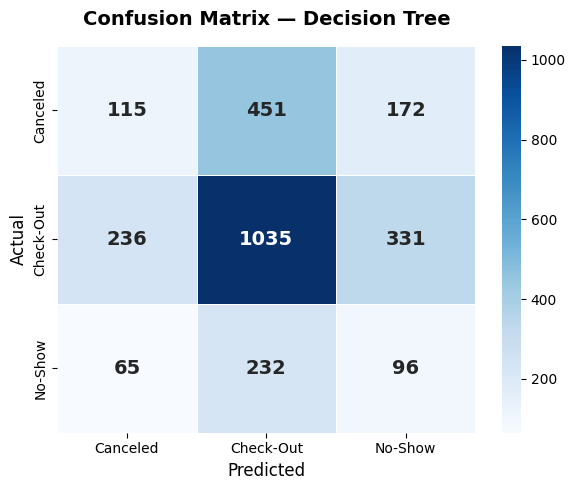


Classification Report:
              precision    recall  f1-score   support

    Canceled       0.28      0.16      0.20       738
   Check-Out       0.60      0.65      0.62      1602
     No-Show       0.16      0.24      0.19       393

    accuracy                           0.46      2733
   macro avg       0.35      0.35      0.34      2733
weighted avg       0.45      0.46      0.45      2733



In [17]:
if best_model_name in ["Logistic Regression", "ANN"]:
    y_pred_cm = final_model.predict(X_val_scaled)
else:
    y_pred_cm = final_model.predict(X_val)

cm = confusion_matrix(y_val_enc, y_pred_cm)
labels = le.classes_

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'},
            ax=ax)
ax.set_title(f'Confusion Matrix — {best_model_name}',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DSPL/chart2_confusion_matrix.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print()
print("Classification Report:")
print(classification_report(y_val_enc, y_pred_cm,
                            target_names=labels))

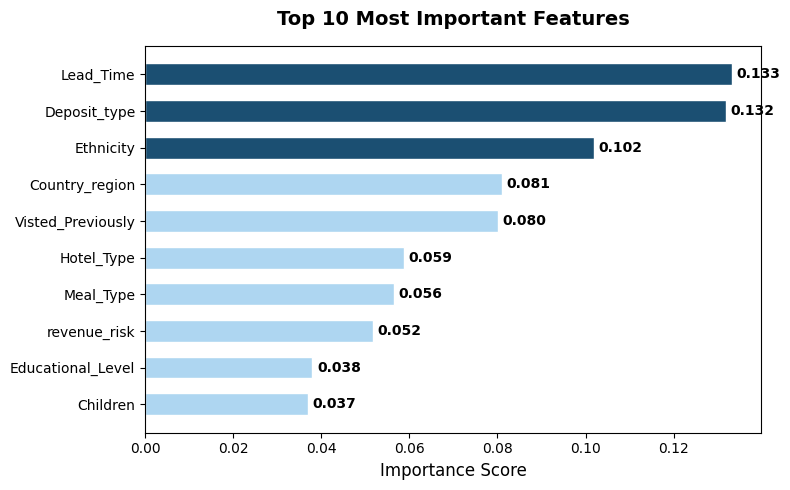

Top 10 features:
Lead_Time            0.133225
Deposit_type         0.131883
Ethnicity            0.101911
Country_region       0.080985
Visted_Previously    0.080131
Hotel_Type           0.058881
Meal_Type            0.056427
revenue_risk         0.051797
Educational_Level    0.038007
Children             0.037035
dtype: float64


In [18]:
if best_model_name in ["Decision Tree",
                        "Random Forest",
                        "XGBoost"]:
    importances = pd.Series(
        final_model.feature_importances_,
        index=X_train.columns)
    top10 = importances.sort_values(ascending=True).tail(10)

    colors = ['#1B4F72' if i >= 7 else '#AED6F1'
              for i in range(10)]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(top10.index, top10.values,
                   color=colors, edgecolor='white',
                   height=0.6)
    for bar, val in zip(bars, top10.values):
        ax.text(bar.get_width() + 0.001,
                bar.get_y() + bar.get_height()/2,
                f'{val:.3f}',
                va='center', fontsize=10,
                fontweight='bold')
    ax.set_title('Top 10 Most Important Features',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Importance Score', fontsize=12)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/DSPL/chart3_feature_importance.png',
                dpi=200, bbox_inches='tight',
                facecolor='white')
    plt.show()
    print("Top 10 features:")
    print(importances.sort_values(ascending=False).head(10))

else:
    print(f"{best_model_name} does not have feature importance.")
    print("Use SHAP values for ANN/LR feature importance.")

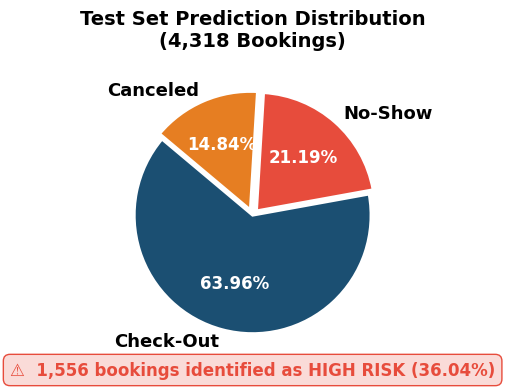


Prediction counts:
Check-Out    2762
No-Show       915
Canceled      641
Name: count, dtype: int64

High risk: 1,556 (36.04%)


In [19]:
pred_counts = pd.Series(test_pred_labels).value_counts()
total = len(test_pred_labels)

colors_pie = ['#1B4F72', '#E74C3C', '#E67E22']
explode = (0, 0.05, 0.05)

fig, ax = plt.subplots(figsize=(6, 4))
wedges, texts, autotexts = ax.pie(
    pred_counts.values,
    labels=pred_counts.index,
    autopct=lambda pct: f'{pct:.2f}%',
    colors=colors_pie,
    explode=explode,
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2))

for text in texts:
    text.set_fontsize(13)
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax.set_title(f'Test Set Prediction Distribution\n({total:,} Bookings)',
             fontsize=14, fontweight='bold', pad=15)

total_risk = (pred_counts.get('Canceled', 0) +
              pred_counts.get('No-Show', 0))
risk_pct = total_risk/total*100

ax.text(0, -1.35,
        f'⚠  {total_risk:,} bookings identified as HIGH RISK ({risk_pct:.2f}%)',
        ha='center', fontsize=12,
        fontweight='bold', color='#E74C3C',
        bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='#FADBD8',
                  edgecolor='#E74C3C'))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DSPL/chart4_test_predictions.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f"\nPrediction counts:")
print(pred_counts)
print(f"\nHigh risk: {total_risk:,} ({risk_pct:.2f}%)")

In [20]:
import os

path = '/content/drive/MyDrive/DSPL/'

train_orig = pd.read_csv(path + 'Hotel-A-train.csv')
train_orig['Reservation_Status'] = train_orig['Reservation_Status'].replace(
    {'Check-out': 'Check-Out'})
train_orig['Expected_checkin'] = pd.to_datetime(train_orig['Expected_checkin'])
train_orig['Expected_checkout'] = pd.to_datetime(train_orig['Expected_checkout'])
train_orig['Booking_date'] = pd.to_datetime(train_orig['Booking_date'])
train_orig['Lead_Time'] = (train_orig['Expected_checkin'] -
                           train_orig['Booking_date']).dt.days
train_orig['Length_of_Stay'] = (train_orig['Expected_checkout'] -
                                train_orig['Expected_checkin']).dt.days
train_orig = train_orig[train_orig['Lead_Time'] >= 0]
train_orig = train_orig[train_orig['Length_of_Stay'] > 0]
train_orig = train_orig.dropna(subset=['Room_Rate'])
train_orig['Revenue'] = train_orig['Room_Rate'] * train_orig['Length_of_Stay']

lost = train_orig[train_orig['Reservation_Status'] != 'Check-Out']['Revenue'].sum()
total_rev = train_orig['Revenue'].sum()

print("=== REVENUE ANALYSIS ===")
print(f"Total revenue: £{total_rev:,.0f}")
print(f"Revenue lost: £{lost:,.0f}")
print(f"% lost: {lost/total_rev*100:.1f}%")
print(f"Average per cancellation: £{lost/len(train_orig[train_orig['Reservation_Status'] != 'Check-Out']):,.0f}")

=== REVENUE ANALYSIS ===
Total revenue: £8,632,858
Revenue lost: £1,985,459
% lost: 23.0%
Average per cancellation: £319


In [21]:
print("RECOMMENDATION DATA VERIFICATION ")
print(f"Clean dataset: {len(train_orig):,} rows")
print()

# Lead time
high_lead = train_orig[train_orig['Lead_Time'] > 100]
high_cancel = high_lead[high_lead['Reservation_Status'] != 'Check-Out']
print(f"Bookings >100 days: {len(high_lead):,}")
print(f"Cancelled/No-show: {len(high_cancel):,}")
print(f"Cancellation rate: {len(high_cancel)/len(high_lead)*100:.1f}%")
print()

# No deposit
no_dep = train_orig[train_orig['Deposit_type'] == 'No Deposit']
no_dep_cancel = no_dep[no_dep['Reservation_Status'] != 'Check-Out']
print(f"No deposit bookings: {len(no_dep):,}")
print(f"Cancelled/No-show: {len(no_dep_cancel):,}")
print(f"Cancellation rate: {len(no_dep_cancel)/len(no_dep)*100:.1f}%")
print()

# Visited previously
first = train_orig[train_orig['Visted_Previously'] == 'No']
first_cancel = first[first['Reservation_Status'] != 'Check-Out']
ret = train_orig[train_orig['Visted_Previously'] == 'Yes']
ret_cancel = ret[ret['Reservation_Status'] != 'Check-Out']
print(f"First-time: {len(first):,}, rate: {len(first_cancel)/len(first)*100:.1f}%")
print(f"Returning: {len(ret):,}, rate: {len(ret_cancel)/len(ret)*100:.1f}%")
print()

print(f"Revenue lost: £{lost:,.0f}")
print(f"Total revenue: £{total_rev:,.0f}")
print(f"% lost: {lost/total_rev*100:.1f}%")

RECOMMENDATION DATA VERIFICATION 
Clean dataset: 26,993 rows

Bookings >100 days: 13,838
Cancelled/No-show: 3,385
Cancellation rate: 24.5%

No deposit bookings: 17,891
Cancelled/No-show: 4,187
Cancellation rate: 23.4%

First-time: 18,001, rate: 23.2%
Returning: 8,992, rate: 22.6%

Revenue lost: £1,985,459
Total revenue: £8,632,858
% lost: 23.0%
